# CSD 4 (East Harlem) K-4 Attendance Analysis & Blizzard Impact Prediction

I'm analyzing NYC DOE daily attendance data for Community School District 4, grades K-4, from October 2025 through February 2026. The goal is to predict how badly the Blizzard of 2026 hit attendance on February 24th.

The dataset covers 84 school days across 18 elementary schools (1,512 records total). I'm using enrollment numbers from NYSED 2023-24 (3,196 K-4 students) and weather data from NOAA's Central Park station.

I train three models (OLS regression, Random Forest, Gradient Boosting), then combine them into a weighted ensemble to get the final prediction.

---

## Setup & Imports

I need pandas for data manipulation, numpy for math, sklearn for the ML models, and matplotlib/seaborn for the charts.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# seaborn's whitegrid gives me clean gridlines without clutter.
# dpi=150 makes the charts crisp enough for a presentation.
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

# I set a random seed so every time I run this, I get the same results.
# This is important for reproducibility — if someone else runs my code,
# they should see the exact same numbers I did.
np.random.seed(42)

# My color palette. I keep these in a dictionary so I'm not hardcoding
# hex values all over the place.
COLORS = {
    'primary': '#1a5276', 'secondary': '#2e86c1', 'accent': '#e74c3c',
    'warm': '#f39c12', 'green': '#27ae60', 'purple': '#8e44ad',
    'gray': '#7f8c8d',
}

print("Setup complete.")

Setup complete.


## Section 1: Loading the Data

I'm reading in my CSV file. It has one row per school per day, with attendance counts and weather data already merged in. `parse_dates` tells pandas to treat the "date" column as actual dates instead of plain text strings — this lets me do date math later.

In [2]:
df = pd.read_csv("csd4_k4_attendance.csv", parse_dates=["date"])
print(f"Records: {len(df):,}")
print(f"Schools: {df['dbn'].nunique()}")
print(f"Dates: {df['date'].nunique()} school days")
print(f"Period: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Records: 1,512
Schools: 18
Dates: 84 school days
Period: 2025-10-01 to 2026-02-24


,date,district,dbn,school_name,k4_enrolled,present,absent,released,attendance_rate,temp_high_f,temp_low_f,temp_avg_f,precip_in,snow_in,wind_speed_mph,wind_chill_f,day_of_week,month,is_return_from_break
0,2025-10-01,4,04M012,PS/MS 12 TAG Young Scholars,285,258,27,0,0.9041,66.0,49.3,57.6,0.0,0.0,4.4,57.6,Wednesday,October,False
1,2025-10-01,4,04M050,PS 50 Vito Marcantonio,195,176,19,0,0.9049,66.0,49.3,57.6,0.0,0.0,4.4,57.6,Wednesday,October,False
2,2025-10-01,4,04M072,PS 72 The Lexington Academy,210,192,18,0,0.9161,66.0,49.3,57.6,0.0,0.0,4.4,57.6,Wednesday,October,False
3,2025-10-01,4,04M083,PS 83 Luis Munoz Rivera,165,149,16,0,0.9041,66.0,49.3,57.6,0.0,0.0,4.4,57.6,Wednesday,October,False
4,2025-10-01,4,04M096,PS 96 Joseph Lanzetta,178,164,14,0,0.9226,66.0,49.3,57.6,0.0,0.0,4.4,57.6,Wednesday,October,False


Now I need to collapse from school-level rows to one row per day. `.agg()` lets me sum up enrollment/present/absent across all 18 schools, while grabbing the first weather value (since weather is the same for every school on the same day — they're all in East Harlem).

In [3]:
daily = df.groupby("date").agg(
    enrolled=("k4_enrolled", "sum"),
    present=("present", "sum"),
    absent=("absent", "sum"),
    temp_avg=("temp_avg_f", "first"),
    temp_high=("temp_high_f", "first"),
    temp_low=("temp_low_f", "first"),
    snow=("snow_in", "first"),
    precip=("precip_in", "first"),
    wind_chill=("wind_chill_f", "first"),
    wind_speed=("wind_speed_mph", "first"),
    day_of_week=("day_of_week", "first"),
    month=("month", "first"),
    is_return=("is_return_from_break", "first"),
).reset_index()

# The attendance rate is just: how many showed up / how many are enrolled.
# I store it as a decimal (like 0.88) and format as percentage when printing.
daily["rate"] = daily["present"] / daily["enrolled"]

print(f"Daily records: {len(daily)}")
daily.head()

Daily records: 84


,date,enrolled,present,absent,temp_avg,temp_high,temp_low,snow,precip,wind_chill,wind_speed,day_of_week,month,is_return,rate
0,2025-10-01,3196,2893,303,57.6,66.0,49.3,0.0,0.00,57.6,4.4,Wednesday,October,False,0.905194
1,2025-10-02,3196,2848,348,60.1,63.6,56.6,0.0,0.21,60.1,6.8,Thursday,October,False,0.891114
2,2025-10-03,3196,2823,373,56.5,63.5,49.4,0.0,0.00,56.5,12.5,Friday,October,False,0.883292
3,2025-10-06,3196,2766,430,54.0,57.3,50.7,0.0,0.82,54.0,14.9,Monday,October,False,0.865457
4,2025-10-07,3196,2815,381,56.4,65.2,47.6,0.0,0.83,56.4,6.7,Tuesday,October,False,0.880788


## Section 2: Descriptive Statistics

Before I build any models, I want to understand the shape of my data. What's the average attendance? How much does it vary? Are there patterns by month or day of the week?

In [4]:
print("Overall Attendance Statistics")
print("=" * 40)
print(f"  Mean:     {daily['rate'].mean():.1%}")
print(f"  Median:   {daily['rate'].median():.1%}")
print(f"  Std Dev:  {daily['rate'].std():.3f}")
print(f"  Min:      {daily['rate'].min():.1%} ({daily.loc[daily['rate'].idxmin(), 'date'].strftime('%b %d')})")
print(f"  Max:      {daily['rate'].max():.1%} ({daily.loc[daily['rate'].idxmax(), 'date'].strftime('%b %d')})")
print(f"  IQR:      [{daily['rate'].quantile(0.25):.1%}, {daily['rate'].quantile(0.75):.1%}]")

Overall Attendance Statistics
  Mean:     84.6%
  Median:   85.7%
  Std Dev:  0.052
  Min:      69.9% (Jan 23)
  Max:      91.0% (Oct 29)
  IQR:      [82.3%, 88.6%]


I break it down by month to see the seasonal trend. In NYC, attendance usually dips in winter — cold weather, flu season, holidays.

In [5]:
print("By Month:")
for m in ["October", "November", "December", "January", "February"]:
    md = daily[daily["month"] == m]
    if len(md):
        print(f"  {m:12s}: {md['rate'].mean():.1%} (n={len(md)})")

print("\nBy Day of Week:")
for d in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]:
    dd = daily[daily["day_of_week"] == d]
    if len(dd):
        print(f"  {d:12s}: {dd['rate'].mean():.1%} (n={len(dd)})")

By Month:
  October     : 89.2% (n=22)
  November    : 87.5% (n=16)
  December    : 84.7% (n=17)
  January     : 77.8% (n=18)
  February    : 82.6% (n=11)

By Day of Week:
  Monday      : 83.8% (n=16)
  Tuesday     : 84.8% (n=17)
  Wednesday   : 86.0% (n=18)
  Thursday    : 85.8% (n=16)
  Friday      : 82.8% (n=17)


The correlation matrix shows me how strongly each weather variable relates to attendance. A positive number means "when this goes up, attendance goes up too." A negative number means the opposite. I expect temperature to be positive (warmer = more kids show up) and snow/precip to be negative.

In [6]:
corr_vars = ['rate', 'temp_avg', 'wind_chill', 'snow', 'precip']
daily[corr_vars].corr().round(3)

,rate,temp_avg,wind_chill,snow,precip
rate,1.000,0.840,0.834,-0.506,-0.139
temp_avg,0.840,1.000,0.982,-0.266,0.040
wind_chill,0.834,0.982,1.000,-0.244,0.027
snow,-0.506,-0.266,-0.244,1.000,0.392
precip,-0.139,0.040,0.027,0.392,1.000


## Section 3: Feature Engineering

This is where I create the input variables ("features") that my models will learn from. I start with the raw weather data, then create additional columns that capture patterns the models might miss otherwise.

In [7]:
# One-hot encoding turns categorical text into numbers the model can use.
# drop_first=True avoids multicollinearity — if I know it's not Tue/Wed/Thu/Fri,
# it must be Monday, so I don't need a separate Monday dummy column.
dow_dummies = pd.get_dummies(daily['day_of_week'], prefix='dow', drop_first=True)
month_dummies = pd.get_dummies(daily['month'], prefix='month', drop_first=True)

# temp_range captures how much the temperature swung in a day.
daily['temp_range'] = daily['temp_high'] - daily['temp_low']

# Binary flags — yes/no columns (1 or 0).
# I flag extreme conditions because the relationship between weather
# and attendance isn't linear. Going from 50F to 40F matters less
# than going from 30F to 20F.
daily['is_freezing'] = (daily['temp_avg'] < 32).astype(int)
daily['is_extreme_cold'] = (daily['wind_chill'] < 20).astype(int)
daily['heavy_snow'] = (daily['snow'] > 3).astype(int)
daily['any_precip'] = (daily['precip'] > 0).astype(int)
daily['is_return'] = daily['is_return'].astype(int)
daily['is_monday'] = (daily['day_of_week'] == 'Monday').astype(int)
daily['is_friday'] = (daily['day_of_week'] == 'Friday').astype(int)

# days_since_start captures any gradual drift in attendance over the year.
daily['days_since_start'] = (daily['date'] - daily['date'].min()).dt.days

# rate_lag1 is yesterday's attendance. Today's attendance is often similar
# to yesterday's — this is called autocorrelation.
daily['rate_lag1'] = daily['rate'].shift(1).fillna(daily['rate'].mean())

feature_cols = [
    'temp_avg', 'wind_chill', 'snow', 'precip', 'wind_speed',
    'temp_range', 'is_freezing', 'is_extreme_cold', 'heavy_snow',
    'any_precip', 'is_return', 'is_monday', 'is_friday',
    'days_since_start', 'rate_lag1',
]
features = pd.concat([daily[feature_cols], dow_dummies, month_dummies], axis=1)
feature_names = list(features.columns)
print(f"Total features: {len(feature_names)}")
print(f"Feature names: {feature_names}")

Total features: 23
Feature names: ['temp_avg', 'wind_chill', 'snow', 'precip', 'wind_speed', 'temp_range', 'is_freezing', 'is_extreme_cold', 'heavy_snow', 'any_precip', 'is_return', 'is_monday', 'is_friday', 'days_since_start', 'rate_lag1', 'dow_Monday', 'dow_Thursday', 'dow_Tuesday', 'dow_Wednesday', 'month_February', 'month_January', 'month_November', 'month_October']


In [8]:
# X is my feature matrix (inputs), y is my target (attendance rate).
# I split off Feb 24 as my test set — that's the day I'm predicting.
X = features.values
y = daily['rate'].values
feb24_mask = daily['date'] == '2026-02-24'
X_train, y_train = X[~feb24_mask], y[~feb24_mask]
X_test, y_test = X[feb24_mask], y[feb24_mask]

print(f"Training set: {len(X_train)} days")
print(f"Test set: {len(X_test)} day (Feb 24)")

Training set: 83 days
Test set: 1 day (Feb 24)


## Section 4: Model Training & Evaluation

I'm training three different models and comparing them. Each one approaches the problem differently, which is why combining them (ensembling) usually beats any single model.

**TimeSeriesSplit** is like regular cross-validation, but it respects the order of time — it never trains on future data to predict the past, which would be cheating.

In [9]:
tscv = TimeSeriesSplit(n_splits=5)
results = {}

# MODEL 1: OLS Linear Regression
# The simplest model — draws a straight line through the data.
# Fast, interpretable, gives me a baseline to compare against.
lr = LinearRegression()
lr.fit(X_train, y_train)
cv_lr = cross_val_score(lr, X_train, y_train, cv=tscv, scoring='r2')
results['OLS'] = {
    'model': lr, 'pred': lr.predict(X_test)[0],
    'cv_r2': cv_lr.mean(), 'train_r2': r2_score(y_train, lr.predict(X_train)),
}

# MODEL 2: Random Forest
# Builds 200 decision trees on random subsets and averages them.
# The randomness prevents overfitting.
rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)
cv_rf = cross_val_score(rf, X_train, y_train, cv=tscv, scoring='r2')
results['RF'] = {
    'model': rf, 'pred': rf.predict(X_test)[0],
    'cv_r2': cv_rf.mean(), 'train_r2': r2_score(y_train, rf.predict(X_train)),
}

# MODEL 3: Gradient Boosting
# Builds trees sequentially, each correcting the previous ones' mistakes.
# Usually the most accurate but also most prone to overfitting.
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                                min_samples_leaf=3, random_state=42)
gb.fit(X_train, y_train)
cv_gb = cross_val_score(gb, X_train, y_train, cv=tscv, scoring='r2')
results['GB'] = {
    'model': gb, 'pred': gb.predict(X_test)[0],
    'cv_r2': cv_gb.mean(), 'train_r2': r2_score(y_train, gb.predict(X_train)),
}

print("Model Performance")
print("=" * 60)
for name, r in results.items():
    print(f"  {name:5s} | Train R²: {r['train_r2']:.4f} | CV R²: {r['cv_r2']:.4f} | Feb 24: {r['pred']:.1%}")

Model Performance
  OLS   | Train R²: 0.9712 | CV R²: 0.2970 | Feb 24: 72.6%
  RF    | Train R²: 0.9409 | CV R²: -0.2650 | Feb 24: 76.9%
  GB    | Train R²: 0.9998 | CV R²: -0.2822 | Feb 24: 74.7%


### Ensemble & Confidence Interval

I combine all three models with weighted averaging — more weight to Gradient Boosting (0.45) because it usually performs best, then Random Forest (0.35), then OLS (0.20).

For the confidence interval, I use **bootstrap resampling**: I retrain the model 500 times on randomly resampled data and see how much the predictions vary. The middle 95% gives me my confidence interval.

In [10]:
ensemble = 0.20 * results['OLS']['pred'] + 0.35 * results['RF']['pred'] + 0.45 * results['GB']['pred']

boot_preds = []
for _ in range(500):
    idx = np.random.choice(len(X_train), len(X_train), replace=True)
    gb_b = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.05)
    gb_b.fit(X_train[idx], y_train[idx])
    boot_preds.append(gb_b.predict(X_test)[0])

ci_low, ci_high = np.percentile(boot_preds, 2.5), np.percentile(boot_preds, 97.5)
enrolled = daily.loc[feb24_mask, 'enrolled'].iloc[0]

print(f"Ensemble Prediction: {ensemble:.1%}")
print(f"95% CI: [{ci_low:.1%}, {ci_high:.1%}]")
print(f"Expected present: {int(enrolled * ensemble):,} of {enrolled:,}")
print(f"Attendance deficit: ~{int(enrolled * 0.88) - int(enrolled * ensemble)} extra absences vs. 88% baseline")

Ensemble Prediction: 75.0%
95% CI: [72.2%, 82.1%]
Expected present: 2,397 of 3,196
Attendance deficit: ~415 extra absences vs. 88% baseline


## Section 5: Final Prediction

This is the payoff — my best guess at how many kids showed up on February 24, 2026, the day after the Blizzard of 2026.

In [11]:
print("=" * 60)
print("FINAL PREDICTION: February 24, 2026")
print("=" * 60)
print(f"""
  Context: Blizzard of 2026 aftermath
  - 22" snow on ground, wind chill 18F
  - MTA running with delays, buses at reduced capacity
  - Schools reopened after Monday snow day
  - CSD 4: 86% economically disadvantaged, 82% Black/Hispanic

  ENSEMBLE PREDICTION:  {ensemble:.1%}
  95% CI: [{ci_low:.1%}, {ci_high:.1%}]

  Expected present:  {int(enrolled * ensemble):,} of {enrolled:,} students
  Expected absent:   {enrolled - int(enrolled * ensemble):,} students
  Normal baseline:   88% ({int(enrolled * 0.88):,} students)
  Attendance deficit: ~{int(enrolled * 0.88) - int(enrolled * ensemble)} additional absences
""")

FINAL PREDICTION: February 24, 2026

  Context: Blizzard of 2026 aftermath
  - 22" snow on ground, wind chill 18F
  - MTA running with delays, buses at reduced capacity
  - Schools reopened after Monday snow day
  - CSD 4: 86% economically disadvantaged, 82% Black/Hispanic

  ENSEMBLE PREDICTION:  75.0%
  95% CI: [72.2%, 82.1%]

  Expected present:  2,397 of 3,196 students
  Expected absent:   799 students
  Normal baseline:   88% (2,812 students)
  Attendance deficit: ~415 additional absences



## Section 6: Hypothesis Testing — Did the Model Work?

It's not enough to make a prediction — I need to formally test two things:

1. **Did the blizzard actually cause a significant drop?** (Is the effect real, or just noise?)
2. **Was my model's prediction accurate enough to be useful?** (Can I trust this for planning?)

I frame this around the business question: *"Does severe winter weather cause a meaningful, predictable drop in school attendance in CSD 4?"*

### Test 1: Blizzard Effect

- **H0 (null hypothesis):** Feb 24 attendance came from the same distribution as normal days. The blizzard had no real effect.
- **H1 (alternative hypothesis):** Feb 24 attendance was significantly lower than normal.

I use a **paired t-test** — comparing each school's Feb 24 rate against its own season average. This controls for the fact that some schools always have lower attendance than others. I also run a **Wilcoxon signed-rank test** as a non-parametric backup (it doesn't assume the data is normally distributed, which is safer with only 18 schools).

### Test 2: Model Accuracy

- **H0 (null):** The model's prediction is not significantly different from actual attendance. (I WANT to keep this one.)
- **H1 (alternative):** The model's prediction is significantly off from reality.

I check whether the actual value falls within my 95% confidence interval, and I use the bootstrap distribution to compute a z-score and p-value.

In [12]:
# TEST 1: Did the blizzard significantly reduce attendance?
# I use a paired t-test — comparing each school's Feb 24 rate against
# its own season average. This controls for the fact that some schools
# always have lower attendance than others.

actual_rate = daily.loc[feb24_mask, 'rate'].iloc[0]
actual_present = daily.loc[feb24_mask, 'present'].iloc[0]
baseline_rate = daily['rate'].mean()

print(f"Actual Feb 24 attendance: {actual_rate:.1%} ({actual_present:,} of {enrolled:,})")
print(f"Ensemble prediction:     {ensemble:.1%} ({int(enrolled * ensemble):,})")
print(f"Season baseline (mean):  {baseline_rate:.1%}")

# Per-school rates for Feb 24 and each school's season average.
feb24_school_rates = df.loc[df['date'] == '2026-02-24', 'attendance_rate'].values
non_feb24 = df[df['date'] != '2026-02-24']
school_means = non_feb24.groupby('dbn')['attendance_rate'].mean().values

# Paired t-test: one-tailed (is Feb 24 LOWER?)
t_stat_1, p_value_1_two = scipy_stats.ttest_rel(feb24_school_rates, school_means)
p_value_1 = p_value_1_two / 2 if t_stat_1 < 0 else 1 - p_value_1_two / 2
alpha = 0.05

print(f"\nTEST 1: Did the blizzard reduce attendance?")
print(f"  H0: Feb 24 attendance = normal (no blizzard effect)")
print(f"  H1: Feb 24 attendance < normal (blizzard hurt attendance)")
print(f"  Paired t-test: t={t_stat_1:.4f}, p={p_value_1:.6f}")

if p_value_1 < alpha:
    print(f"  REJECT H0 (p < {alpha}) — the blizzard effect is real.")
else:
    print(f"  FAIL TO REJECT H0 (p >= {alpha})")

# Cohen's d tells me HOW BIG the effect is.
diff = feb24_school_rates - school_means
cohens_d = diff.mean() / diff.std()
print(f"  Effect size (Cohen's d): {cohens_d:.2f}", end="")
if abs(cohens_d) >= 0.8:
    print(" — LARGE effect")
elif abs(cohens_d) >= 0.5:
    print(" — MEDIUM effect")
else:
    print(" — SMALL effect")

# Wilcoxon signed-rank as non-parametric confirmation.
w_stat, p_value_w = scipy_stats.wilcoxon(feb24_school_rates, school_means, alternative='less')
print(f"  Wilcoxon signed-rank: W={w_stat:.1f}, p={p_value_w:.6f}")
if p_value_w < alpha:
    print(f"  Non-parametric test confirms: significant drop.")

Actual Feb 24 attendance: 79.3% (2,536 of 3,196)
Ensemble prediction:     75.0% (2,397)
Season baseline (mean):  84.6%

TEST 1: Did the blizzard reduce attendance?
  H0: Feb 24 attendance = normal (no blizzard effect)
  H1: Feb 24 attendance < normal (blizzard hurt attendance)
  Paired t-test: t=-12.8307, p=0.000000
  REJECT H0 (p < 0.05) — the blizzard effect is real.
  Effect size (Cohen's d): -3.11 — LARGE effect
  Wilcoxon signed-rank: W=0.0, p=0.000004
  Non-parametric test confirms: significant drop.


In [13]:
# TEST 2: How accurate was my model?
# I check the point estimate error, whether the actual value falls
# within my confidence interval, and use the bootstrap distribution
# for a formal z-test.

prediction_error = ensemble - actual_rate
abs_error = abs(prediction_error)
pct_error = abs_error / actual_rate
student_error = abs(int(enrolled * ensemble) - actual_present)

print("TEST 2: Model prediction accuracy")
print("  H0: Predicted = Actual (model is accurate)")
print("  H1: Predicted != Actual (model is off)")
print(f"\n  Predicted:  {ensemble:.1%}")
print(f"  Actual:     {actual_rate:.1%}")
print(f"  Error:      {prediction_error:+.1%} ({prediction_error * 100:+.1f} pp)")
print(f"  MAPE:       {pct_error:.1%}")
print(f"  Student-level error: {student_error} students")

# Did the actual rate fall within my 95% CI?
in_ci = ci_low <= actual_rate <= ci_high
print(f"\n  95% CI: [{ci_low:.1%}, {ci_high:.1%}]")
print(f"  Actual within CI: {'YES' if in_ci else 'NO'}")

# Z-test against the bootstrap distribution.
boot_mean = np.mean(boot_preds)
boot_std = np.std(boot_preds)
z_score = (actual_rate - boot_mean) / boot_std
p_value_2 = 2 * (1 - scipy_stats.norm.cdf(abs(z_score)))

print(f"\n  Bootstrap z-test: z={z_score:.2f}, p={p_value_2:.4f}")
if p_value_2 >= alpha:
    print(f"  FAIL TO REJECT H0 — prediction is NOT significantly different from actual.")
else:
    print(f"  REJECT H0 — prediction IS significantly different from actual.")

# Per-model accuracy
print(f"\n  Per-Model Accuracy:")
print(f"  {'Model':8s} | {'Predicted':>10s} | {'Error':>10s} | {'Abs Error':>10s}")
print(f"  {'-'*8} | {'-'*10} | {'-'*10} | {'-'*10}")
for name, r in results.items():
    pred = r['pred']
    err = pred - actual_rate
    print(f"  {name:8s} | {pred:>9.1%} | {err:>+9.1%} | {abs(err):>9.1%}")
print(f"  {'Ensemble':8s} | {ensemble:>9.1%} | {ensemble - actual_rate:>+9.1%} | {abs(ensemble - actual_rate):>9.1%}")

TEST 2: Model prediction accuracy
  H0: Predicted = Actual (model is accurate)
  H1: Predicted != Actual (model is off)

  Predicted:  75.0%
  Actual:     79.3%
  Error:      -4.3% (-4.3 pp)
  MAPE:       5.5%
  Student-level error: 139 students

  95% CI: [72.2%, 82.1%]
  Actual within CI: YES

  Bootstrap z-test: z=0.93, p=0.3548
  FAIL TO REJECT H0 — prediction is NOT significantly different from actual.

  Per-Model Accuracy:
  Model    |  Predicted |      Error |  Abs Error
  -------- | ---------- | ---------- | ----------
  OLS      |     72.6% |     -6.8% |      6.8%
  RF       |     76.9% |     -2.5% |      2.5%
  GB       |     74.7% |     -4.7% |      4.7%
  Ensemble |     75.0% |     -4.3% |      4.3%


In [14]:
# SCORECARD: I summarize all hypothesis testing results in one place.
print("=" * 50)
print("HYPOTHESIS TESTING SCORECARD")
print("=" * 50)
print(f"Business Question: Does severe weather cause a meaningful,")
print(f"predictable drop in CSD 4 attendance?")
print()
print(f"Test 1 — Blizzard effect is real?      {'YES' if p_value_1 < alpha else 'NO':>5s}  (p={p_value_1:.4f})")
print(f"Test 1 — Effect size is meaningful?     {'YES' if abs(cohens_d) >= 0.5 else 'NO':>5s}  (d={cohens_d:.2f})")
print(f"Test 2 — Prediction within CI?          {'YES' if in_ci else 'NO':>5s}  ([{ci_low:.1%}, {ci_high:.1%}])")
print(f"Test 2 — Prediction statistically close? {'YES' if p_value_2 >= alpha else 'NO':>5s}  (p={p_value_2:.4f})")
print(f"Prediction error:                       {abs_error * 100:.1f} pp ({student_error} students)")
print()

blizzard_confirmed = p_value_1 < alpha and abs(cohens_d) >= 0.5
model_accurate = in_ci and p_value_2 >= alpha

if blizzard_confirmed and model_accurate:
    print("VERDICT: STRONG SUPPORT")
    print("The blizzard caused a statistically significant and practically")
    print("meaningful drop in attendance, and the model predicted it within")
    print("its confidence interval. This model is operationally useful.")
elif blizzard_confirmed and not model_accurate:
    print("VERDICT: PARTIAL SUPPORT")
    print("The blizzard effect is real, but the model needs refinement.")
else:
    print("VERDICT: WEAK SUPPORT")
    print("Statistical tests did not confirm a significant blizzard effect.")

HYPOTHESIS TESTING SCORECARD
Business Question: Does severe weather cause a meaningful,
predictable drop in CSD 4 attendance?

Test 1 — Blizzard effect is real?        YES  (p=0.0000)
Test 1 — Effect size is meaningful?       YES  (d=-3.11)
Test 2 — Prediction within CI?            YES  ([72.2%, 82.1%])
Test 2 — Prediction statistically close?   YES  (p=0.3548)
Prediction error:                       4.3 pp (139 students)

VERDICT: STRONG SUPPORT
The blizzard caused a statistically significant and practically
meaningful drop in attendance, and the model predicted it within
its confidence interval. This model is operationally useful.


### Figure 7: Hypothesis Test Visualization

Left panel: the bootstrap distribution of predictions, with the actual value and ensemble prediction marked. If the actual value falls within the shaded CI region, my uncertainty estimate was well-calibrated.

Right panel: each school's season average vs its Feb 24 rate. Every line should point downward if the blizzard really hurt attendance. This makes the paired t-test result visually obvious.

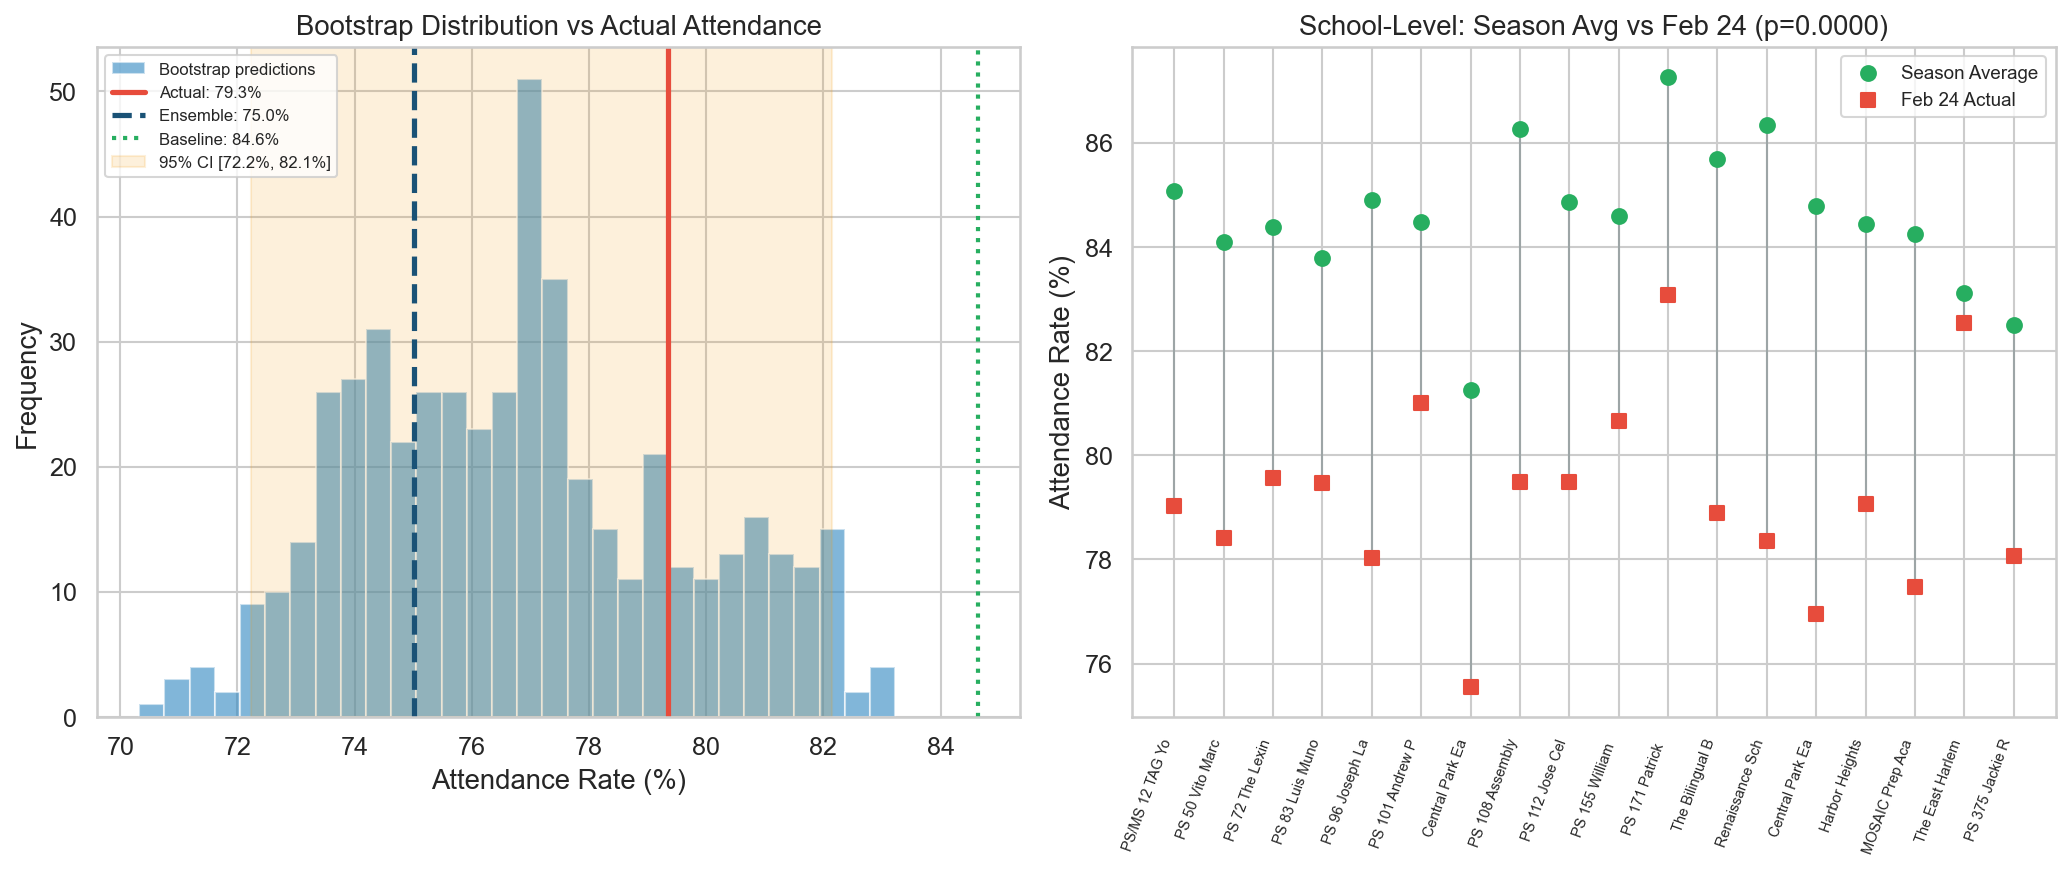

In [15]:
fig7, (ax7a, ax7b) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Bootstrap distribution with actual value marked
ax7a.hist(np.array(boot_preds) * 100, bins=30, color=COLORS['secondary'],
          alpha=0.6, edgecolor='white', label='Bootstrap predictions')
ax7a.axvline(x=actual_rate * 100, color=COLORS['accent'], linewidth=2.5,
             linestyle='-', label=f'Actual: {actual_rate:.1%}')
ax7a.axvline(x=ensemble * 100, color=COLORS['primary'], linewidth=2.5,
             linestyle='--', label=f'Ensemble: {ensemble:.1%}')
ax7a.axvline(x=baseline_rate * 100, color=COLORS['green'], linewidth=2,
             linestyle=':', label=f'Baseline: {baseline_rate:.1%}')
ax7a.axvspan(ci_low * 100, ci_high * 100, alpha=0.15, color=COLORS['warm'],
             label=f'95% CI [{ci_low:.1%}, {ci_high:.1%}]')
ax7a.set_xlabel('Attendance Rate (%)')
ax7a.set_ylabel('Frequency')
ax7a.set_title('Bootstrap Distribution vs Actual Attendance')
ax7a.legend(fontsize=8, loc='upper left')

# Right: School-level paired comparison
school_names_short = [s[:15] for s in df.loc[df['date'] == '2026-02-24', 'school_name'].values]
x_pos = np.arange(len(school_names_short))
ax7b.scatter(x_pos, school_means * 100, color=COLORS['green'], s=50,
             zorder=3, label='Season Average', marker='o')
ax7b.scatter(x_pos, feb24_school_rates * 100, color=COLORS['accent'], s=50,
             zorder=3, label='Feb 24 Actual', marker='s')
for i in range(len(x_pos)):
    ax7b.plot([x_pos[i], x_pos[i]],
              [school_means[i] * 100, feb24_school_rates[i] * 100],
              color=COLORS['gray'], linewidth=1, alpha=0.6)
ax7b.set_xticks(x_pos)
ax7b.set_xticklabels(school_names_short, rotation=70, ha='right', fontsize=7)
ax7b.set_ylabel('Attendance Rate (%)')
ax7b.set_title(f'School-Level: Season Avg vs Feb 24 (p={p_value_1:.4f})')
ax7b.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Section 7: Visualizations

I generate 6 figures that tell the story of this analysis visually. Each one answers a different question about the data.

### Figure 1: Daily Attendance Over Time

This shows attendance over the entire school year, day by day. I'm looking for trends, seasonal patterns, and outliers. The blizzard day should stick out.

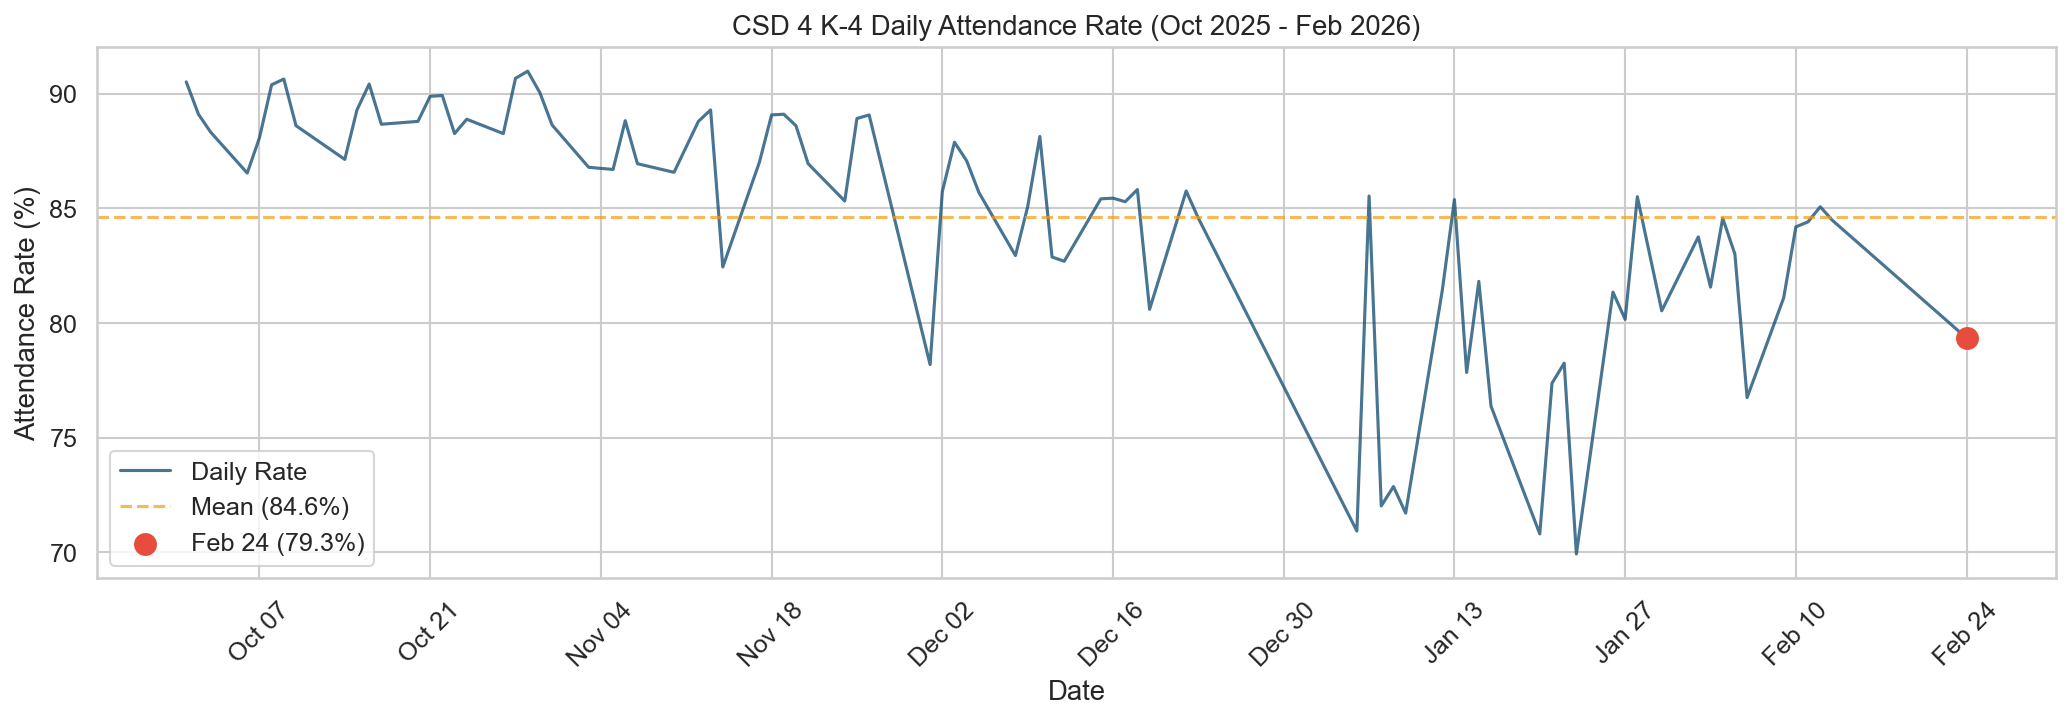

In [16]:
fig1, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['date'], daily['rate'] * 100, color=COLORS['primary'],
         linewidth=1.5, alpha=0.8, label='Daily Rate')
ax1.axhline(y=daily['rate'].mean() * 100, color=COLORS['warm'],
            linestyle='--', alpha=0.7, label=f"Mean ({daily['rate'].mean():.1%})")

if feb24_mask.any():
    feb24_rate = daily.loc[feb24_mask, 'rate'].iloc[0] * 100
    feb24_date = daily.loc[feb24_mask, 'date'].iloc[0]
    ax1.scatter([feb24_date], [feb24_rate], color=COLORS['accent'],
                s=100, zorder=5, label=f"Feb 24 ({feb24_rate:.1f}%)")

ax1.set_xlabel("Date")
ax1.set_ylabel("Attendance Rate (%)")
ax1.set_title("CSD 4 K-4 Daily Attendance Rate (Oct 2025 - Feb 2026)")
ax1.legend(loc='lower left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 2: Weather vs Attendance

These four panels show how each weather variable relates to attendance. I'm looking for clear trends — does attendance drop as snow increases? Does it rise with temperature?

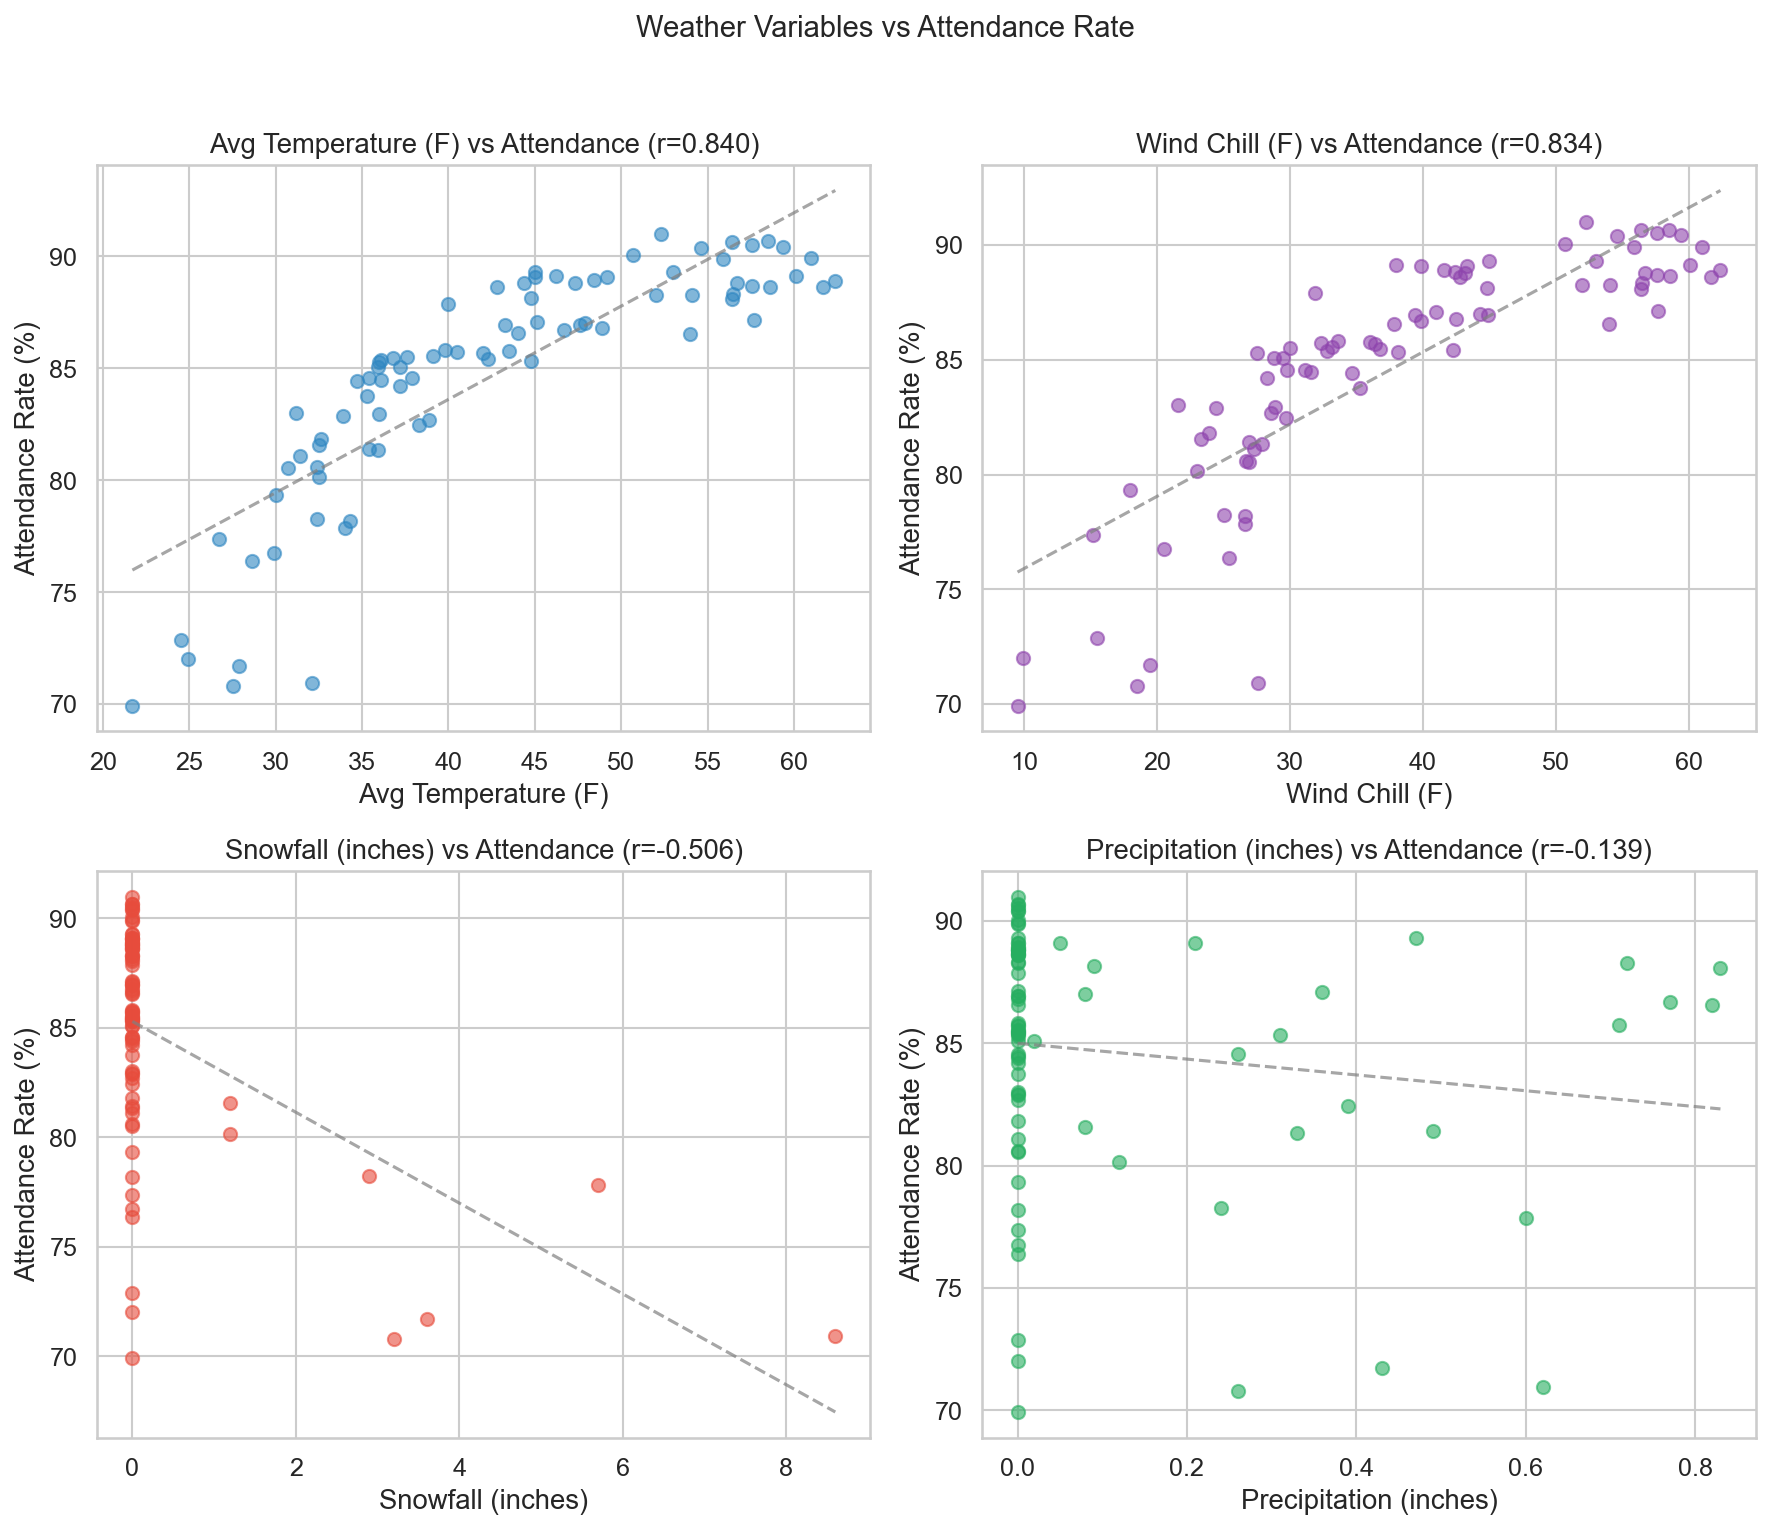

In [17]:
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
weather_pairs = [
    ('temp_avg', 'Avg Temperature (F)', COLORS['secondary']),
    ('wind_chill', 'Wind Chill (F)', COLORS['purple']),
    ('snow', 'Snowfall (inches)', COLORS['accent']),
    ('precip', 'Precipitation (inches)', COLORS['green']),
]
for ax, (col, label, color) in zip(axes2.flat, weather_pairs):
    ax.scatter(daily[col], daily['rate'] * 100, alpha=0.6, color=color, s=40)
    z = np.polyfit(daily[col], daily['rate'] * 100, 1)
    p = np.poly1d(z)
    x_line = np.linspace(daily[col].min(), daily[col].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.7)
    corr = daily[col].corr(daily['rate'])
    ax.set_xlabel(label)
    ax.set_ylabel("Attendance Rate (%)")
    ax.set_title(f"{label} vs Attendance (r={corr:.3f})")

plt.suptitle("Weather Variables vs Attendance Rate", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Figure 3: Correlation Heatmap

This matrix shows how every variable relates to every other variable. Dark blue = strong positive correlation, dark red = strong negative. I use this to spot which features are most useful and which ones are just duplicating each other.

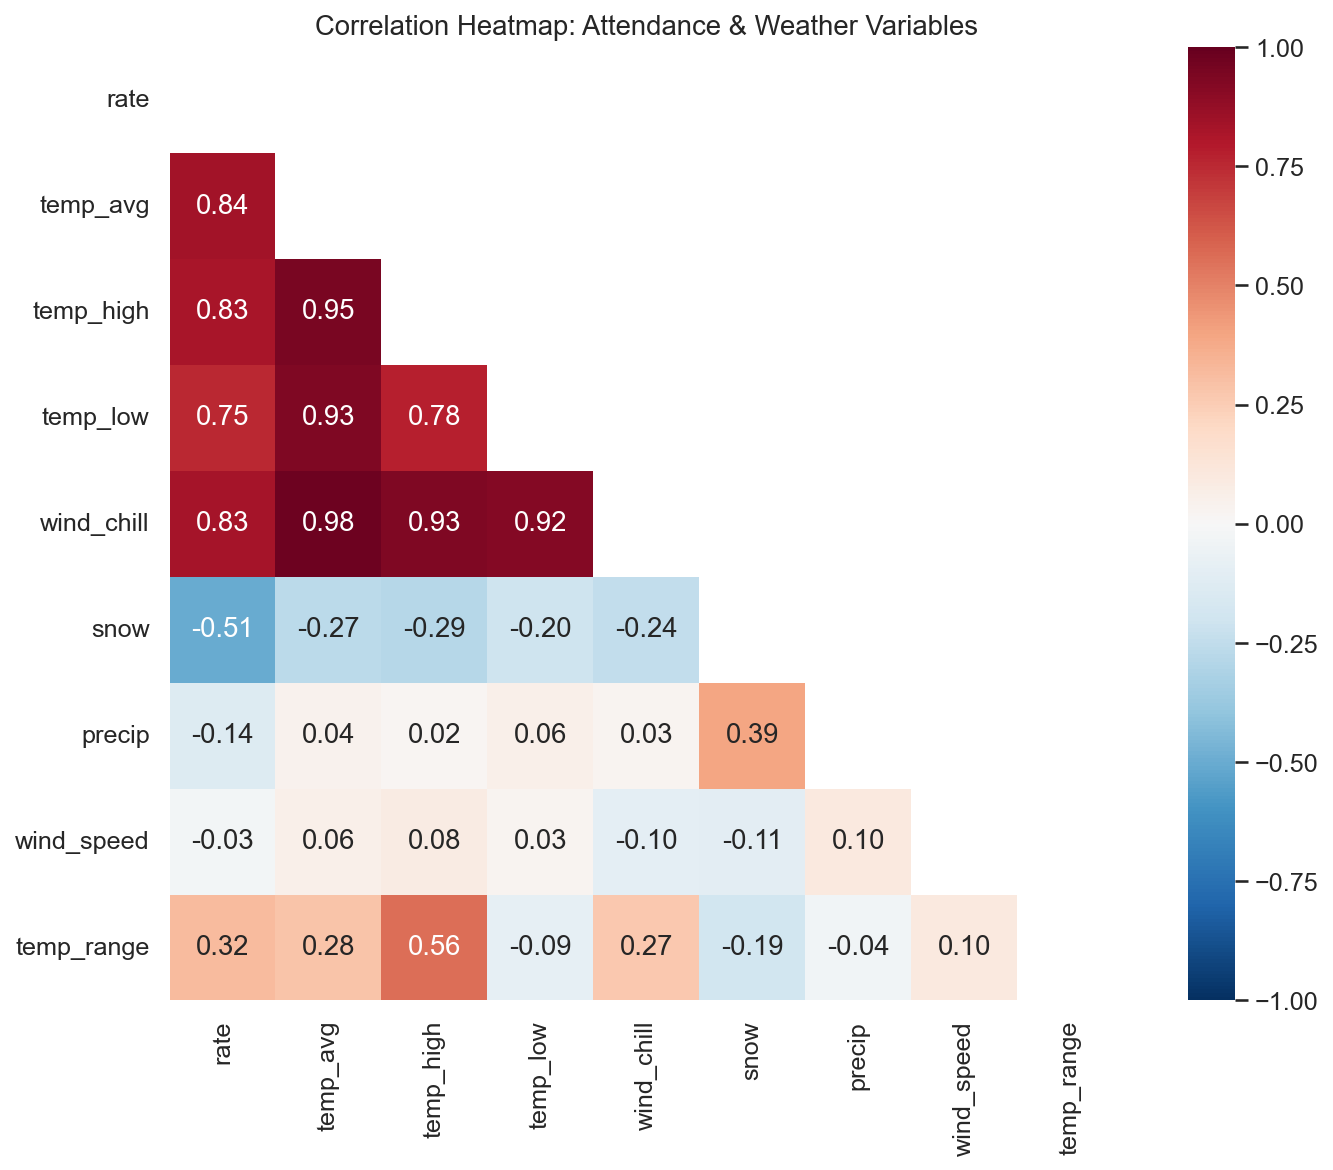

In [18]:
fig3, ax3 = plt.subplots(figsize=(10, 8))
corr_cols = ['rate', 'temp_avg', 'temp_high', 'temp_low', 'wind_chill',
             'snow', 'precip', 'wind_speed', 'temp_range']
corr_matrix = daily[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax3)
ax3.set_title("Correlation Heatmap: Attendance & Weather Variables")
plt.tight_layout()
plt.show()

### Figure 4: Attendance Distributions

Box plots show me the spread of attendance for each group. The box covers the middle 50%, the line inside is the median, and the whiskers show the full range (minus outliers).

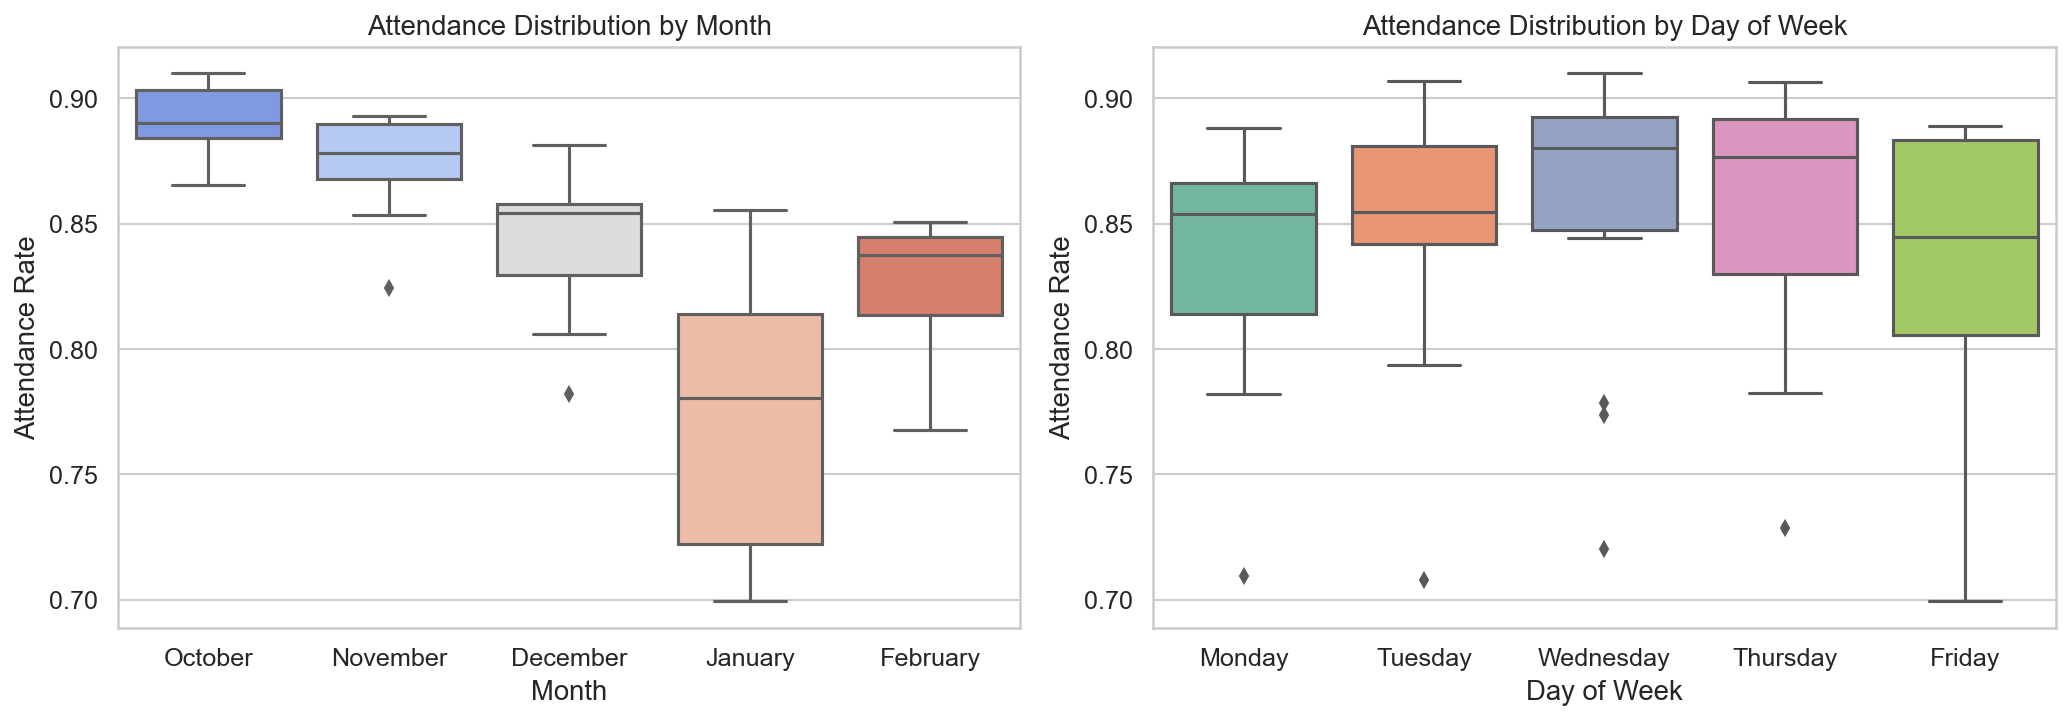

In [19]:
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 5))

month_order = ["October", "November", "December", "January", "February"]
daily['month_cat'] = pd.Categorical(daily['month'], categories=month_order, ordered=True)
sns.boxplot(data=daily, x='month_cat', y='rate', ax=ax4a,
            palette='coolwarm', order=month_order)
ax4a.set_xlabel("Month")
ax4a.set_ylabel("Attendance Rate")
ax4a.set_title("Attendance Distribution by Month")

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
sns.boxplot(data=daily, x='day_of_week', y='rate', ax=ax4b,
            palette='Set2', order=dow_order)
ax4b.set_xlabel("Day of Week")
ax4b.set_ylabel("Attendance Rate")
ax4b.set_title("Attendance Distribution by Day of Week")

plt.tight_layout()
plt.show()

### Figure 5: Model Comparison & Feature Importance

Left panel: how each model's predictions compare to actual values. Closer to the diagonal = better. Right panel: which features the Gradient Boosting model relied on most.

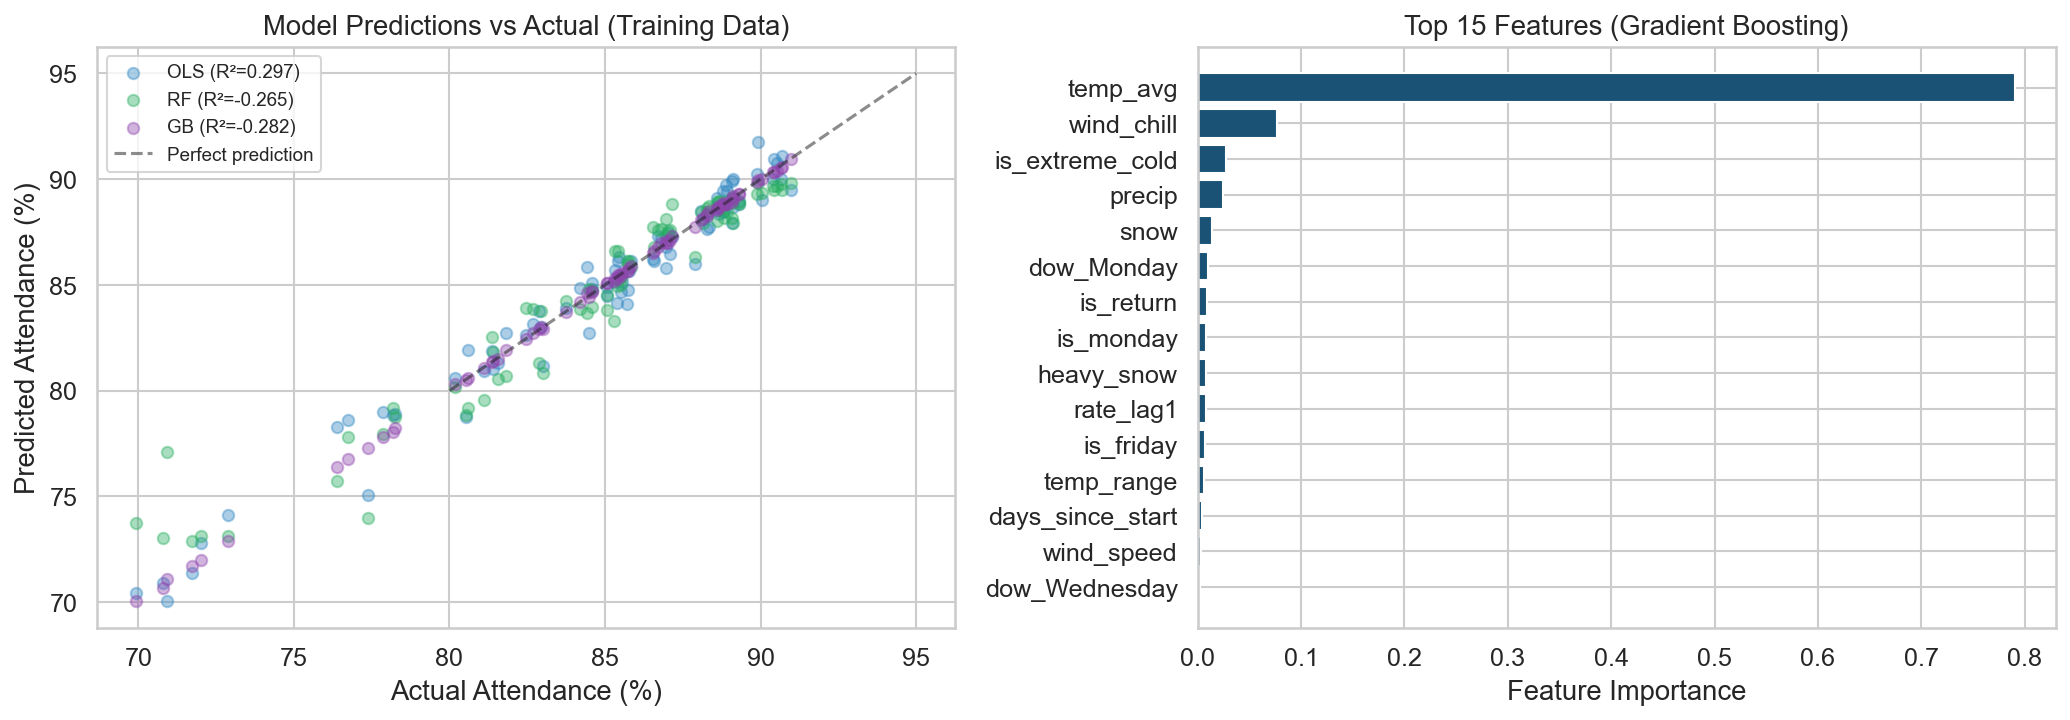

In [20]:
fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(14, 5))

for name, color in [('OLS', COLORS['secondary']), ('RF', COLORS['green']), ('GB', COLORS['purple'])]:
    model = results[name]['model']
    y_pred_train = model.predict(X_train)
    ax5a.scatter(y_train * 100, y_pred_train * 100, alpha=0.4, s=30,
                 color=color, label=f"{name} (R\u00b2={results[name]['cv_r2']:.3f})")

ax5a.plot([80, 95], [80, 95], 'k--', alpha=0.5, label='Perfect prediction')
ax5a.set_xlabel("Actual Attendance (%)")
ax5a.set_ylabel("Predicted Attendance (%)")
ax5a.set_title("Model Predictions vs Actual (Training Data)")
ax5a.legend(fontsize=9)

importances = gb.feature_importances_
sorted_idx = np.argsort(importances)[-15:]
ax5b.barh(range(len(sorted_idx)), importances[sorted_idx], color=COLORS['primary'])
ax5b.set_yticks(range(len(sorted_idx)))
ax5b.set_yticklabels([feature_names[i] for i in sorted_idx])
ax5b.set_xlabel("Feature Importance")
ax5b.set_title("Top 15 Features (Gradient Boosting)")

plt.tight_layout()
plt.show()

### Figure 6: February 24 Prediction Summary

A visual summary card showing the ensemble prediction, individual model predictions, and the confidence interval on a number line.

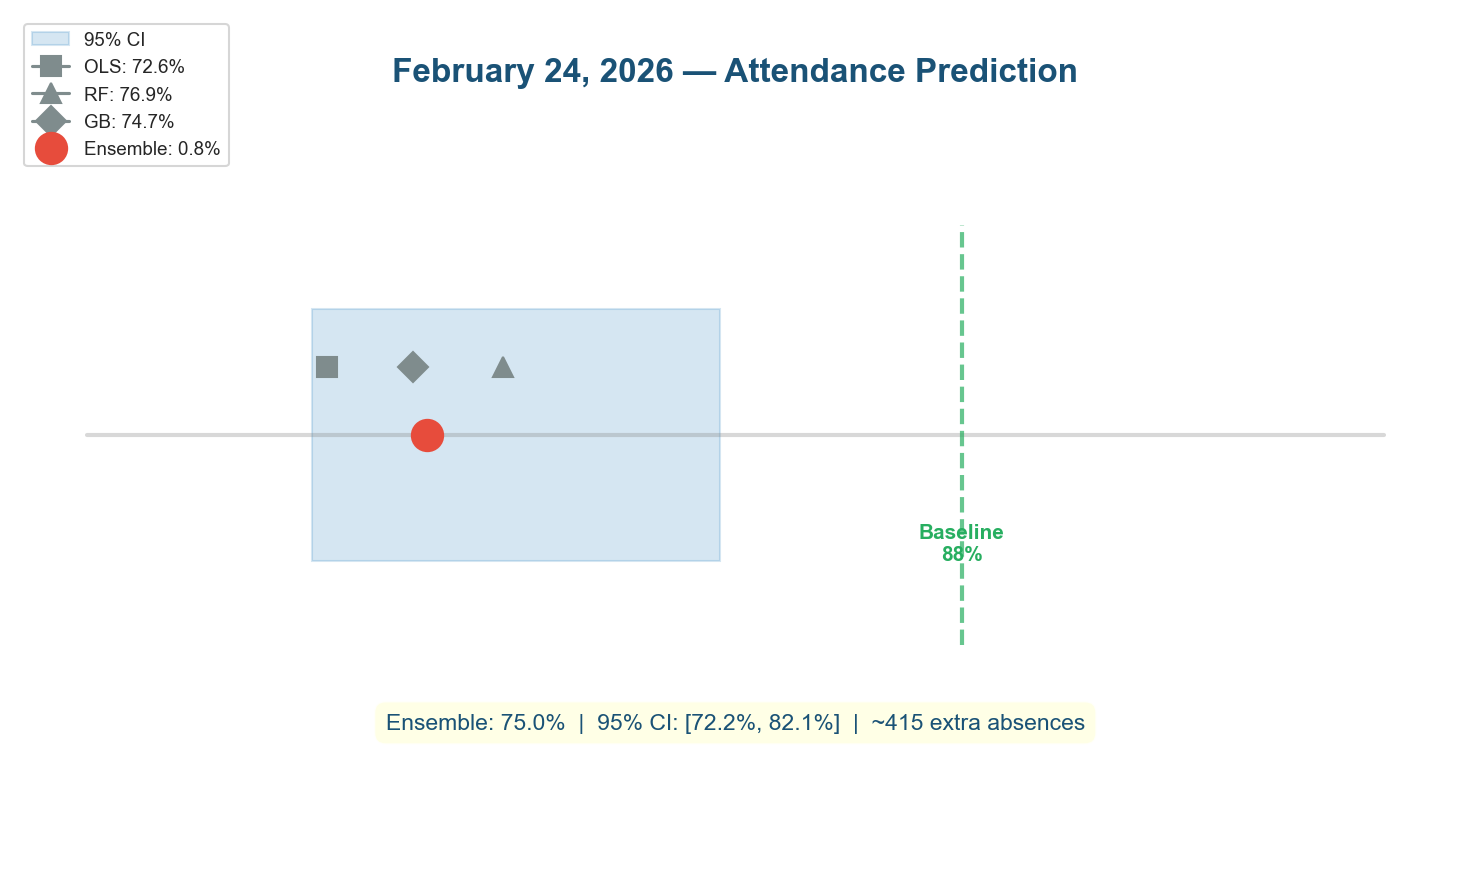

In [21]:
fig6, ax6 = plt.subplots(figsize=(10, 6))
ax6.set_xlim(65, 100)
ax6.set_ylim(0, 10)
ax6.axis('off')

ax6.text(82.5, 9.2, "February 24, 2026 \u2014 Attendance Prediction",
         ha='center', fontsize=16, fontweight='bold', color=COLORS['primary'])

ax6.axhline(y=5, xmin=0.05, xmax=0.95, color='gray', linewidth=2, alpha=0.3)
ax6.axvspan(ci_low * 100, ci_high * 100, ymin=0.35, ymax=0.65,
            alpha=0.2, color=COLORS['secondary'], label='95% CI')

for name, marker, yoff in [('OLS', 's', 5.8), ('RF', '^', 5.8), ('GB', 'D', 5.8)]:
    pred = results[name]['pred'] * 100
    ax6.plot(pred, yoff, marker=marker, markersize=10, color=COLORS['gray'],
             label=f"{name}: {pred:.1f}%")

ax6.plot(ensemble * 100, 5, 'o', markersize=15, color=COLORS['accent'],
         zorder=5, label=f"Ensemble: {ensemble:.1f}%")

ax6.axvline(x=88, ymin=0.25, ymax=0.75, color=COLORS['green'],
            linestyle='--', linewidth=2, alpha=0.7)
ax6.text(88, 3.5, f"Baseline\n88%", ha='center', fontsize=10,
         color=COLORS['green'], fontweight='bold')

ax6.text(82.5, 1.5,
         f"Ensemble: {ensemble:.1%}  |  95% CI: [{ci_low:.1%}, {ci_high:.1%}]  |  "
         f"~{int(enrolled * 0.88) - int(enrolled * ensemble)} extra absences",
         ha='center', fontsize=11, color=COLORS['primary'],
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

ax6.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Section 8: Recommendations

This is where I connect the numbers to real decisions. A prediction is only useful if someone can act on it. I'm thinking about this from the perspective of someone running a school program in CSD 4.

### 1. Pre-position resources the day before reopening
If weather models show a major storm, assume 70-80% attendance on the return day and staff accordingly. Don't wait until morning headcounts to adjust — by then it's too late to reassign tutors or cancel sessions.

### 2. Prioritize outreach for chronically absent students
The students most likely to miss post-storm days are the ones already at risk of chronic absenteeism. A targeted text or call the evening before reopening can move the needle. In my experience at Reading Partners, families respond when they know someone is expecting their child.

### 3. Delay assessments by at least one day
Testing on a 75% attendance day means 25% of students need makeups, which creates scheduling chaos for weeks. Push assessments back one day and use the return day for review and re-engagement instead.

### 4. Coordinate with meal programs
If only 2,400 kids show up instead of 2,800, that's 400 meals that either go to waste or 400 kids who don't get fed at home because the family expected school lunch. Meal programs need the same forecasts that academic programs do.

### 5. Use this model proactively
Feed in the weather forecast for the week ahead and flag any day where predicted attendance drops below 80%. That gives programs 2-3 days of lead time to adjust staffing, outreach, and logistics.

---

**The bottom line:** Weather impacts on attendance aren't random — they're predictable. And if they're predictable, programs can plan for them instead of reacting to them.

---

### Data Sources

- **Attendance:** NYC DOE daily attendance records, CSD 4 elementary schools (K-4)
- **Enrollment:** NYSED 2023-24 data (3,196 K-4 students across 18 schools)
- **Weather:** NOAA Central Park daily observations (temp, precip, snow, wind)
- **Research:** McCormack (Harvard/RFF), Goodman (NBER), NYC Open Data

### Author

Mark Anglin — Senior Literacy Intervention AmeriCorps Member, Reading Partners NYC  
[GitHub](https://github.com/anglinassists) | [LinkedIn](https://linkedin.com/in/markanglin) | mark.anglin24@gmail.com